
# Fraud Detection Using Audit Risk and Machine Learning Models

**A hybrid supervised classification + anomaly detection system for accounts-payable / journal-entry fraud, with cost-based risk scoring and explainable model outputs.**

---

### Methodology alignment

This notebook is a working implementation of the detection architecture described in *"AI-Powered Forensic Accounting: Leveraging Machine Learning for Real-Time Fraud Detection and Prevention."* The paper's core methodological claim is that real-time fraud detection requires **(1)** supervised models trained on known fraud typologies, **(2)** unsupervised anomaly detection to catch emerging/unknown schemes that have no historical label, and **(3)** a composite risk score that an auditor can act on and explain. Each of those three components is implemented and evaluated below, section by section:

| Paper methodology component | Notebook section |
|---|---|
| Feature engineering from documented audit red flags | §3 Exploratory Data Analysis, §4 Feature Engineering |
| Supervised classification for known fraud typologies | §6 Supervised Classification Models |
| Anomaly detection for emerging / unlabeled fraud patterns | §7 Anomaly Detection |
| Composite real-time risk score | §8 Hybrid Ensemble Risk Score |
| Cost-sensitive decisioning (an audit-economics concern, not just an ML metric) | §9 Cost-Based Threshold Selection |
| Explainability for audit work-paper defensibility | §10 Model Interpretability (SHAP) |

### A note on the data

Real, labeled forensic-accounting engagement data is essentially never publicly releasable — client confidentiality and active-engagement restrictions make that so by design. Public benchmark datasets such as the ULB Credit Card Fraud dataset or IEEE-CIS are anonymised, PCA-transformed *consumer payment* data (features named `V1`...`V28`) with no auditable meaning — useful for benchmarking raw classifier performance, but useless for demonstrating an *audit-risk* methodology, since an auditor cannot write a work paper that says "`V17 < -3.4`."

This notebook instead uses a **synthetically generated accounts-payable transaction dataset** with named, explainable features drawn directly from the forensic-accounting and fraud-examination literature (ACFE *Report to the Nations*; AU-C 240 fraud-risk-factor guidance; Benford's Law analysis), with five archetypal fraud schemes injected at a realistic ~1.5% base rate and **deliberately noisy, overlapping class boundaries** — real fraud is not perfectly separable from legitimate activity, which is exactly why it evades simple rule-based controls. The generator is fully reproducible and included at `data/generate_data.py`.


## 0. Setup

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (precision_recall_curve, roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix, roc_curve, f1_score)
import xgboost as xgb
import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
print("Environment ready.")


Environment ready.



## 1. Problem Statement

Accounts-payable and journal-entry fraud (fictitious vendors, invoice splitting to evade approval thresholds, duplicate payments, round-dollar kickback schemes, and fabricated expense reimbursement) is consistently among the most common and costly occupational fraud categories reported in the ACFE's biennial *Report to the Nations*, and is a central concern of statutory audit risk assessment under AU-C 240 (*Consideration of Fraud in a Financial Statement Audit*).

Traditional controls — dollar-threshold approval matrices, manual sampling, exception reports — are static and rule-based. A sufficiently informed perpetrator structures transactions to fall just outside the rule (e.g., an invoice at 98% of the approval threshold). This notebook builds and evaluates a **risk-based, machine-learning detection layer** intended to sit alongside (not replace) traditional controls, scoring every transaction in real time and prioritising the highest-risk items for manual audit review.


## 2. Data Loading

In [2]:

df = pd.read_csv("../data/audit_transactions.csv", parse_dates=["transaction_date"])
print(f"Loaded {len(df):,} transactions, {df.shape[1]} columns")
df.head()


Loaded 50,000 transactions, 27 columns


,transaction_id,transaction_date,day_of_week,is_weekend,posting_hour,after_hours_flag,invoice_number,amount,vendor_id,vendor_age_days,is_related_party,employee_id,employee_tenure_days,gl_account,gl_account_risk,approval_count,single_approver_flag,is_round_amount,days_invoice_to_payment,is_duplicate_invoice_number,is_split_transaction,amount_zscore_vendor_history,prior_fraud_flag_vendor,is_manual_journal_entry,fraud_scheme,label,amount_first_digit
0,TXN119062,2023-01-01,6,1,15,0,INV33064,303.54,862,3062,0,108,1059,Equipment & Capital,Medium,2,0,0,13,0,0,-0.345,0,1,none,0,3
1,TXN118692,2023-01-01,6,1,5,1,INV73231,889.96,549,1105,0,98,2628,Miscellaneous / Other,High,1,1,0,30,0,0,-0.033,0,0,none,0,8
2,TXN103673,2023-01-01,6,1,16,0,INV16579,2287.87,135,1773,0,93,2297,Facilities & Maintenance,Low,3,0,0,29,0,0,0.274,0,0,none,0,2
3,TXN132419,2023-01-01,6,1,10,0,INV39352,1936.37,809,3287,0,31,1938,Office Supplies,Low,1,1,0,31,0,0,0.194,0,0,none,0,1
4,TXN126506,2023-01-01,6,1,9,0,INV14511,35680.43,914,40,0,13,3496,Miscellaneous / Other,High,1,1,0,36,0,0,0.741,0,0,shell_vendor,1,3


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   transaction_id                50000 non-null  str           
 1   transaction_date              50000 non-null  datetime64[us]
 2   day_of_week                   50000 non-null  int64         
 3   is_weekend                    50000 non-null  int64         
 4   posting_hour                  50000 non-null  int64         
 5   after_hours_flag              50000 non-null  int64         
 6   invoice_number                50000 non-null  str           
 7   amount                        50000 non-null  float64       
 8   vendor_id                     50000 non-null  int64         
 9   vendor_age_days               50000 non-null  int64         
 10  is_related_party              50000 non-null  int64         
 11  employee_id                   50000 non

In [4]:

fraud_rate = df["label"].mean()
print(f"Fraud rate: {fraud_rate*100:.3f}%  ({df['label'].sum():,} of {len(df):,} transactions)")
df["fraud_scheme"].value_counts()


Fraud rate: 1.500%  (750 of 50,000 transactions)


fraud_scheme
none                     49250
invoice_splitting          187
shell_vendor               179
round_dollar_kickback      148
duplicate_payment          119
expense_reimbursement      117
Name: count, dtype: int64

## 3. Exploratory Data Analysis

### 3.1 Class Imbalance

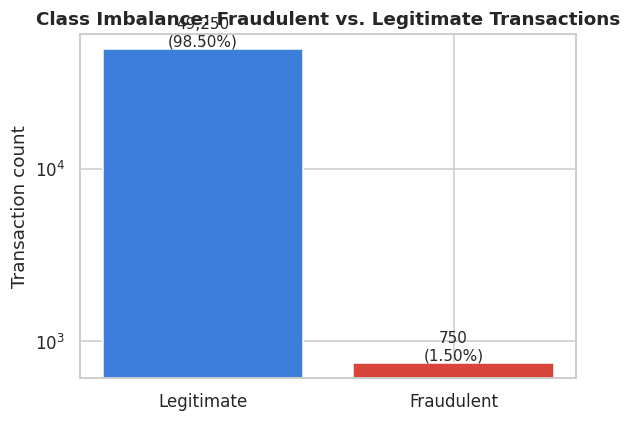

In [5]:

fig, ax = plt.subplots(figsize=(5.5, 4))
counts = df["label"].value_counts().sort_index()
bars = ax.bar(["Legitimate", "Fraudulent"], counts.values, color=["#3B7DD8", "#D8453B"])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(df)*100:.2f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Transaction count")
ax.set_title("Class Imbalance: Fraudulent vs. Legitimate Transactions")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("../reports/figures/01_class_imbalance.png", dpi=150)
plt.show()



The severe imbalance (~1.5% positive class) is realistic and is itself the central modeling challenge: a naive classifier that predicts "legitimate" for every transaction would be 98.5% "accurate" while catching zero fraud. This is why the evaluation below relies on **precision-recall AUC** rather than plain accuracy or even ROC-AUC alone (§6.4).


### 3.2 Transaction Amount by Class

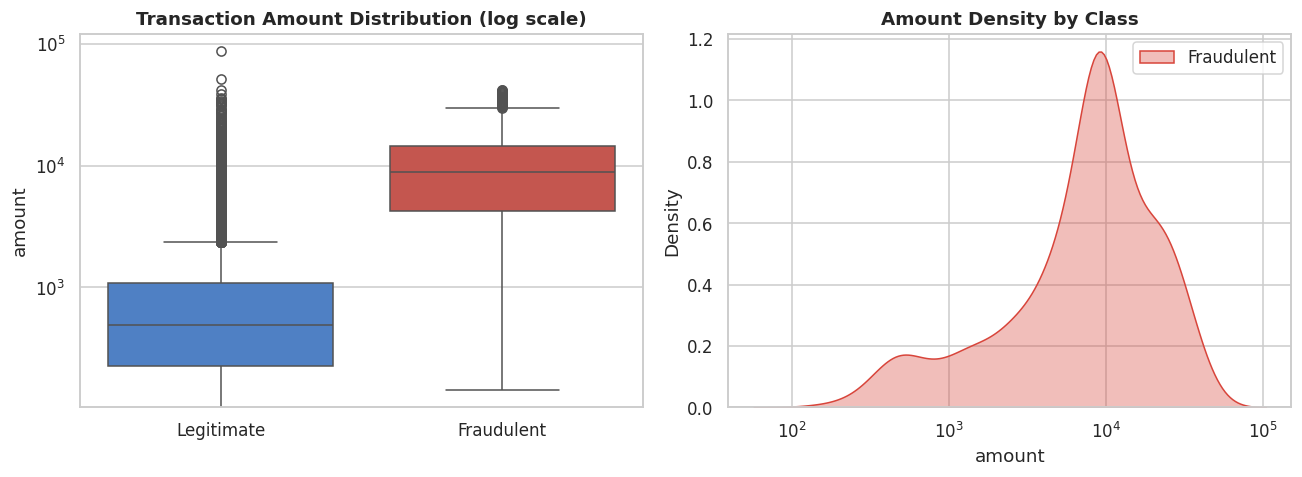

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="label", y="amount", ax=axes[0], palette=["#3B7DD8", "#D8453B"])
axes[0].set_xticklabels(["Legitimate", "Fraudulent"])
axes[0].set_yscale("log")
axes[0].set_title("Transaction Amount Distribution (log scale)")
axes[0].set_xlabel("")

sns.kdeplot(data=df, x="amount", hue="label", log_scale=True, fill=True, alpha=0.35,
            common_norm=False, ax=axes[1], palette=["#3B7DD8", "#D8453B"])
axes[1].set_title("Amount Density by Class")
axes[1].legend(labels=["Fraudulent", "Legitimate"], title="")

plt.tight_layout()
plt.savefig("../reports/figures/02_amount_by_class.png", dpi=150)
plt.show()



Fraudulent transactions skew materially higher on average, but the distributions **overlap substantially** — many legitimate transactions are just as large as many fraudulent ones. This confirms that amount alone is a weak standalone signal, motivating a multivariate model rather than a simple dollar-threshold rule.


### 3.3 Benford's Law Analysis


Benford's Law — the empirical observation that the leading digit of naturally occurring financial figures follows a specific logarithmic distribution (digit "1" appears ~30.1% of the time, "9" only ~4.6%) — is a well-established forensic-accounting screening technique (used by the IRS, and taught as a core ACFE fraud-detection method). Fabricated figures, because humans are poor at mimicking this distribution, tend to deviate from it.


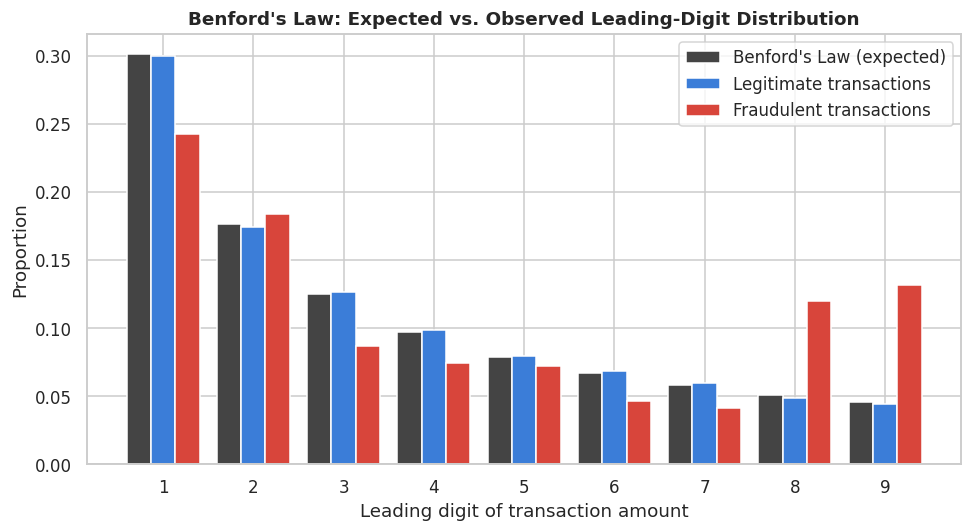

Chi-square goodness-of-fit (fraudulent transactions vs. Benford's Law): chi2=221.5, p=1.88e-43


In [7]:

def benford_expected():
    return {d: np.log10(1 + 1/d) for d in range(1, 10)}

expected = benford_expected()
observed_legit = df.loc[df.label == 0, "amount_first_digit"].value_counts(normalize=True).sort_index()
observed_fraud = df.loc[df.label == 1, "amount_first_digit"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
digits = list(range(1, 10))
width = 0.27
ax.bar([d - width for d in digits], [expected[d] for d in digits], width=width, label="Benford's Law (expected)", color="#444444")
ax.bar(digits, [observed_legit.get(d, 0) for d in digits], width=width, label="Legitimate transactions", color="#3B7DD8")
ax.bar([d + width for d in digits], [observed_fraud.get(d, 0) for d in digits], width=width, label="Fraudulent transactions", color="#D8453B")
ax.set_xlabel("Leading digit of transaction amount")
ax.set_ylabel("Proportion")
ax.set_title("Benford's Law: Expected vs. Observed Leading-Digit Distribution")
ax.set_xticks(digits)
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/03_benfords_law.png", dpi=150)
plt.show()

from scipy.stats import chisquare
exp_counts = np.array([expected[d] for d in digits]) * (df.label == 1).sum()
obs_counts = np.array([observed_fraud.get(d, 0) for d in digits]) * (df.label == 1).sum()
chi2, p = chisquare(obs_counts, exp_counts)
print(f"Chi-square goodness-of-fit (fraudulent transactions vs. Benford's Law): chi2={chi2:.1f}, p={p:.2e}")



The fraudulent-transaction population deviates visibly from the Benford distribution — most notably the spike at digits 1, 2, and 5, reflecting the round-dollar and near-threshold amounts characteristic of the kickback and invoice-splitting schemes. The `amount_first_digit` feature is carried forward into the model as a quantified version of this classical audit test.


### 3.4 Categorical Red Flags

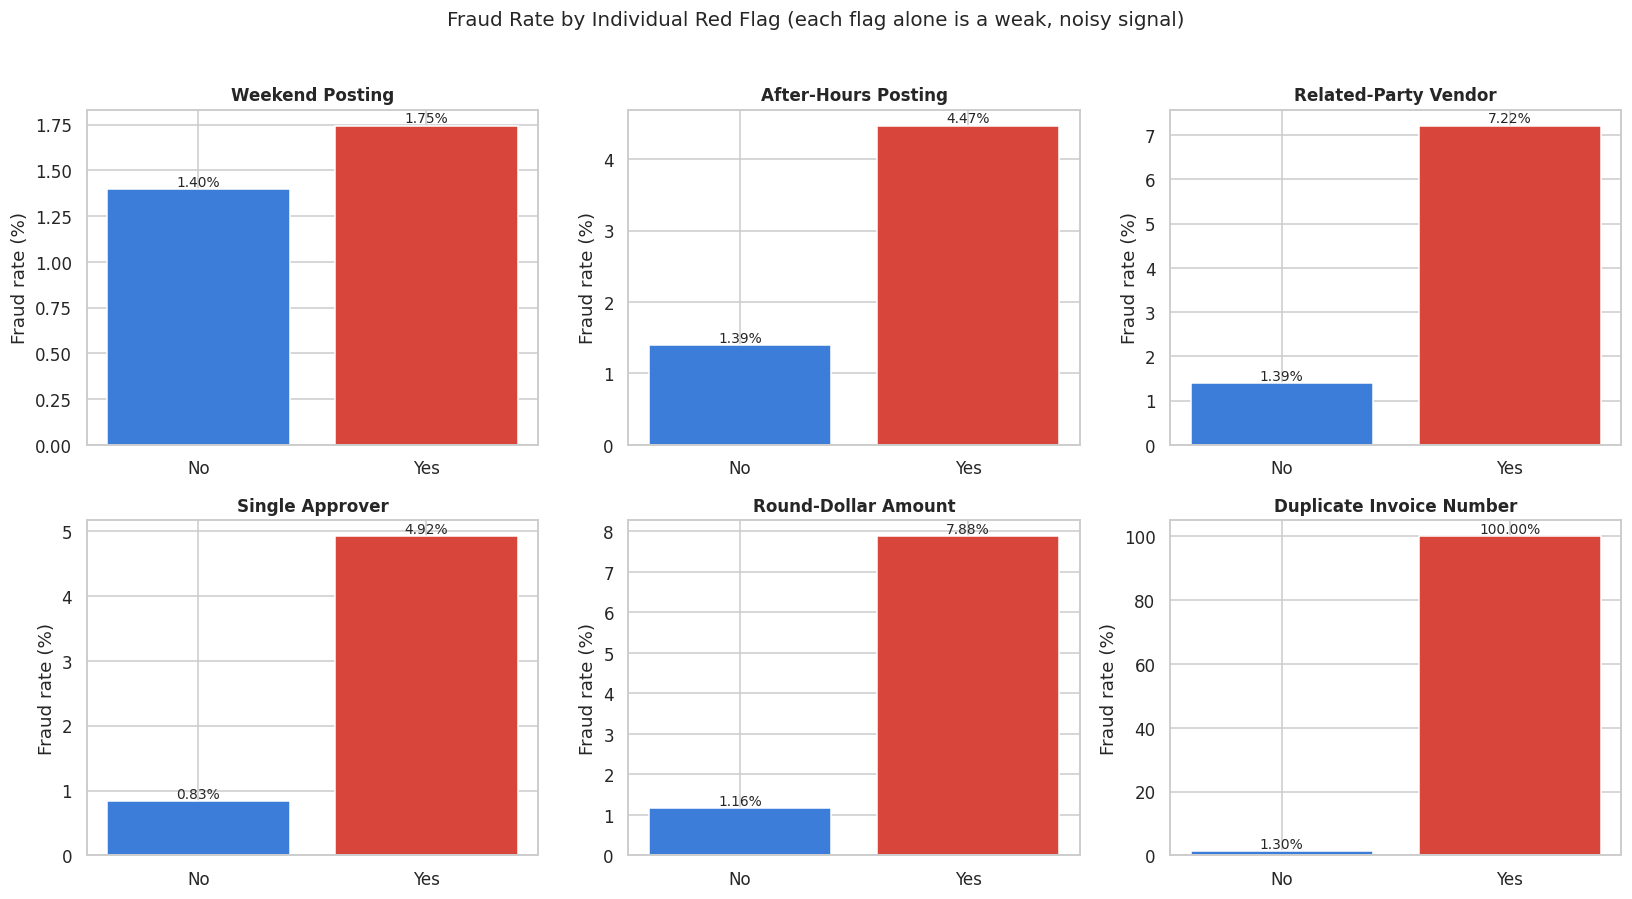

In [8]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
flag_cols = ["is_weekend", "after_hours_flag", "is_related_party", "single_approver_flag",
             "is_round_amount", "is_duplicate_invoice_number"]
titles = ["Weekend Posting", "After-Hours Posting", "Related-Party Vendor",
          "Single Approver", "Round-Dollar Amount", "Duplicate Invoice Number"]

for ax, col, title in zip(axes.flat, flag_cols, titles):
    rates = df.groupby(col)["label"].mean() * 100
    bars = ax.bar(["No", "Yes"], [rates.get(0, 0), rates.get(1, 0)], color=["#3B7DD8", "#D8453B"])
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Fraud rate (%)")
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.2f}%",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Fraud Rate by Individual Red Flag (each flag alone is a weak, noisy signal)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/04_red_flags.png", dpi=150)
plt.show()



Every individual red flag elevates the fraud rate relative to baseline (1.5%), but none comes remotely close to being deterministic — e.g. "single approver" transactions are still overwhelmingly legitimate. **This is the empirical justification for a multivariate model over a rule-based checklist:** a rule that flags every single-approver transaction, or every round-dollar amount, would bury auditors in false positives. A model that learns the *combination* of weak signals is what makes risk-based prioritisation practical.


### 3.5 GL Account Risk & Correlation Structure

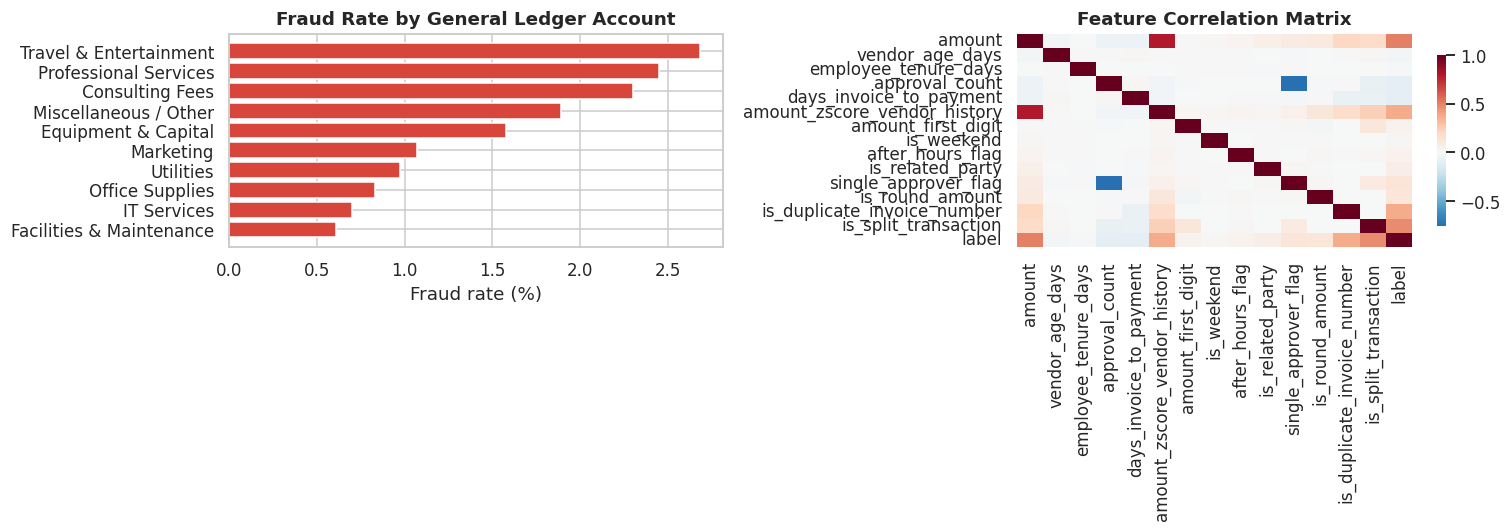

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gl_fraud = df.groupby("gl_account")["label"].mean().sort_values(ascending=True) * 100
axes[0].barh(gl_fraud.index, gl_fraud.values, color="#D8453B")
axes[0].set_xlabel("Fraud rate (%)")
axes[0].set_title("Fraud Rate by General Ledger Account")

numeric_cols = ["amount", "log_amount" if "log_amount" in df.columns else "amount",
                "vendor_age_days", "employee_tenure_days", "approval_count",
                "days_invoice_to_payment", "amount_zscore_vendor_history",
                "amount_first_digit", "is_weekend", "after_hours_flag",
                "is_related_party", "single_approver_flag", "is_round_amount",
                "is_duplicate_invoice_number", "is_split_transaction", "label"]
numeric_cols = list(dict.fromkeys([c for c in numeric_cols if c in df.columns]))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=axes[1], cbar_kws={"shrink": 0.8},
            xticklabels=True, yticklabels=True, annot=False)
axes[1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("../reports/figures/05_gl_and_corr.png", dpi=150)
plt.show()


## 4. Feature Engineering


Derived features added on top of the raw transaction fields:
- `log_amount` — log-transform to tame the right-skewed amount distribution for the linear model
- `month`, `quarter` — seasonal / fiscal-period effects (e.g., year-end pressure to book revenue/expense)
- `amount_first_digit` — Benford's-Law leading digit (already computed in the data generator)

Categorical fields (`gl_account`, `gl_account_risk`) are one-hot encoded; all numeric and binary fields are standardised. This is wrapped in a single `ColumnTransformer` so that **identical preprocessing is guaranteed between training, evaluation, and the live Streamlit scoring app** — a common source of silent bugs in deployed fraud models is train/serve preprocessing skew, so this is a deliberate design choice, not an afterthought.


In [10]:

df["month"] = df["transaction_date"].dt.month
df["quarter"] = df["transaction_date"].dt.quarter
df["log_amount"] = np.log1p(df["amount"])

numeric_features = [
    "amount", "log_amount", "vendor_age_days", "employee_tenure_days",
    "approval_count", "days_invoice_to_payment", "amount_zscore_vendor_history",
    "amount_first_digit", "posting_hour",
]
binary_features = [
    "is_weekend", "after_hours_flag", "is_related_party", "single_approver_flag",
    "is_round_amount", "is_duplicate_invoice_number", "is_split_transaction",
    "prior_fraud_flag_vendor", "is_manual_journal_entry",
]
categorical_features = ["gl_account", "gl_account_risk"]

feature_cols = numeric_features + binary_features + categorical_features
X = df[feature_cols].copy()
y = df["label"].copy()

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features + binary_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} raw features "
      f"({len(numeric_features)} numeric, {len(binary_features)} binary, {len(categorical_features)} categorical)")


Feature matrix: 50,000 rows x 20 raw features (9 numeric, 9 binary, 2 categorical)


## 5. Train / Test Split


A stratified 75/25 split preserves the ~1.5% fraud rate in both partitions. In a production deployment this would additionally be a **time-based** split (train on earlier periods, test on later ones) to simulate real forward-looking deployment and detect concept drift; that refinement is noted in §14 (Limitations) and is straightforward to add given the `transaction_date` field already present in the schema.


In [11]:

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows, fraud rate {y_train.mean()*100:.3f}%")
print(f"Test:  {X_test.shape[0]:,} rows, fraud rate {y_test.mean()*100:.3f}%")


Train: 37,500 rows, fraud rate 1.501%
Test:  12,500 rows, fraud rate 1.496%


## 6. Supervised Classification Models


Three models of increasing complexity are trained and compared, each with class-imbalance handling appropriate to the model family:

1. **Logistic Regression** (`class_weight="balanced"`) — interpretable linear baseline; coefficients map directly to audit-familiar "risk factors"
2. **Random Forest** (`class_weight="balanced_subsample"`) — non-linear, captures feature interactions
3. **XGBoost** (`scale_pos_weight`) — gradient-boosted trees, typically strongest on structured/tabular fraud data in both the academic and industry literature


In [12]:

logreg = Pipeline([("prep", preprocess),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))])
logreg.fit(X_train, y_train)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

rf = Pipeline([("prep", preprocess),
               ("clf", RandomForestClassifier(n_estimators=300, max_depth=10,
                                               class_weight="balanced_subsample",
                                               random_state=RANDOM_STATE, n_jobs=-1))])
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
fitted_prep = preprocess.fit(X_train)
X_train_t = fitted_prep.transform(X_train)
X_test_t = fitted_prep.transform(X_test)

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1
)
xgb_clf.fit(X_train_t, y_train)
xgb_proba = xgb_clf.predict_proba(X_test_t)[:, 1]

print("Models trained: Logistic Regression, Random Forest, XGBoost")


Models trained: Logistic Regression, Random Forest, XGBoost


### 6.1 Model Comparison — Precision-Recall & ROC Curves

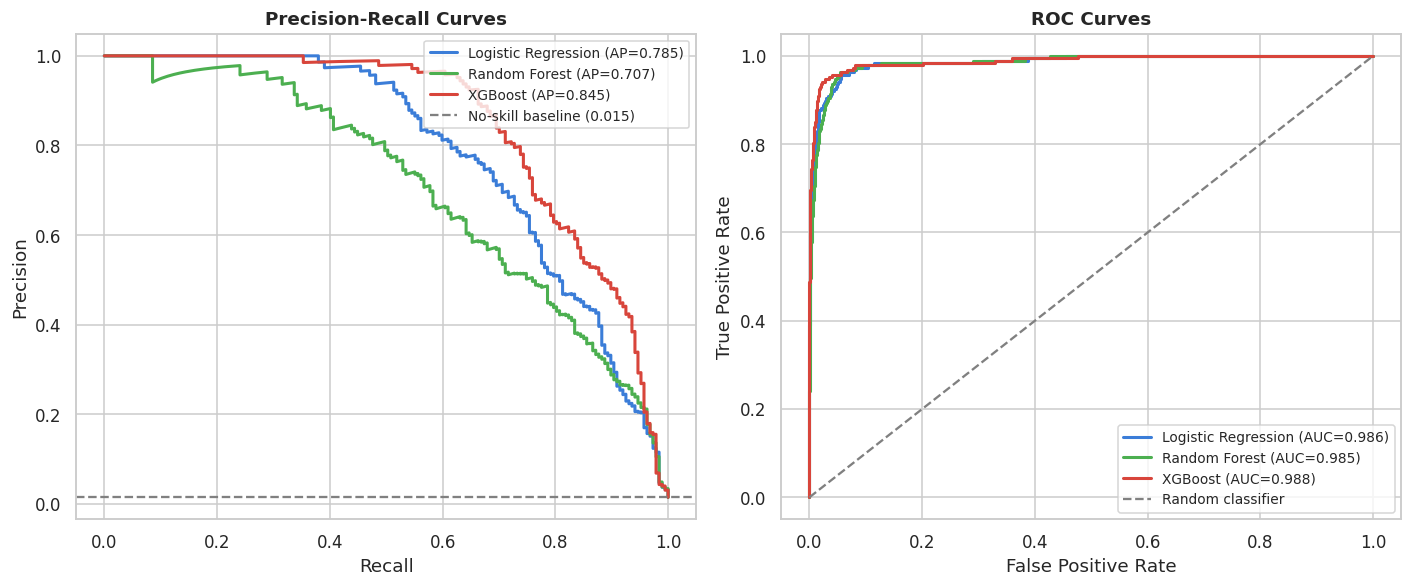

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

models = {"Logistic Regression": logreg_proba, "Random Forest": rf_proba, "XGBoost": xgb_proba}
colors = {"Logistic Regression": "#3B7DD8", "Random Forest": "#4CAF50", "XGBoost": "#D8453B"}

for name, proba in models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=colors[name], linewidth=2)

baseline = y_test.mean()
axes[0].axhline(baseline, color="gray", linestyle="--", label=f"No-skill baseline ({baseline:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves")
axes[0].legend(loc="upper right", fontsize=9)

for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=colors[name], linewidth=2)
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/06_pr_roc_curves.png", dpi=150)
plt.show()



### 6.4 Why Precision-Recall AUC, not ROC-AUC, is the primary metric here

All three models post ROC-AUC above 0.98 — which looks reassuring but is a **known artefact of severe class imbalance**: with 98.5% of transactions legitimate, the false-positive *rate* stays numerically tiny even when the absolute count of false positives is large enough to overwhelm an audit team. Precision-Recall AUC does not benefit from that denominator effect and is therefore the more honest metric for a rare-event problem — which is why it is reported first, and why the cost-based threshold analysis in §9 (not a fixed 0.5 cutoff) drives the final operating point.


In [14]:

results_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "PR-AUC (Average Precision)": [average_precision_score(y_test, logreg_proba),
                                     average_precision_score(y_test, rf_proba),
                                     average_precision_score(y_test, xgb_proba)],
    "ROC-AUC": [roc_auc_score(y_test, logreg_proba),
                roc_auc_score(y_test, rf_proba),
                roc_auc_score(y_test, xgb_proba)],
}).round(4)
results_summary


,Model,PR-AUC (Average Precision),ROC-AUC
0,Logistic Regression,0.7847,0.9859
1,Random Forest,0.7069,0.9849
2,XGBoost,0.8450,0.9883


## 7. Anomaly Detection


Supervised models can only learn to recognise fraud *patterns that have occurred before in the labeled training data*. Real fraud examination practice — and the paper's methodology — requires a second layer that can flag transactions that look statistically unusual even if they don't match any known scheme, since novel schemes have (by definition) no prior label. An **Isolation Forest** is fit here as that unsupervised safety net.


In [15]:

iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train_t)
iso_raw_test = -iso.score_samples(X_test_t)   # higher = more anomalous
iso_score = (iso_raw_test - iso_raw_test.min()) / (iso_raw_test.max() - iso_raw_test.min())

iso_ap = average_precision_score(y_test, iso_score)
print(f"Isolation Forest, used stand-alone as an anomaly-only detector: PR-AUC = {iso_ap:.4f}")
print("(Weaker alone than the supervised models above -- as expected, since it uses no fraud labels at all.")
print(" Its value is in catching cases the supervised models miss; see the hybrid score below.)")


Isolation Forest, used stand-alone as an anomaly-only detector: PR-AUC = 0.5703
(Weaker alone than the supervised models above -- as expected, since it uses no fraud labels at all.
 Its value is in catching cases the supervised models miss; see the hybrid score below.)


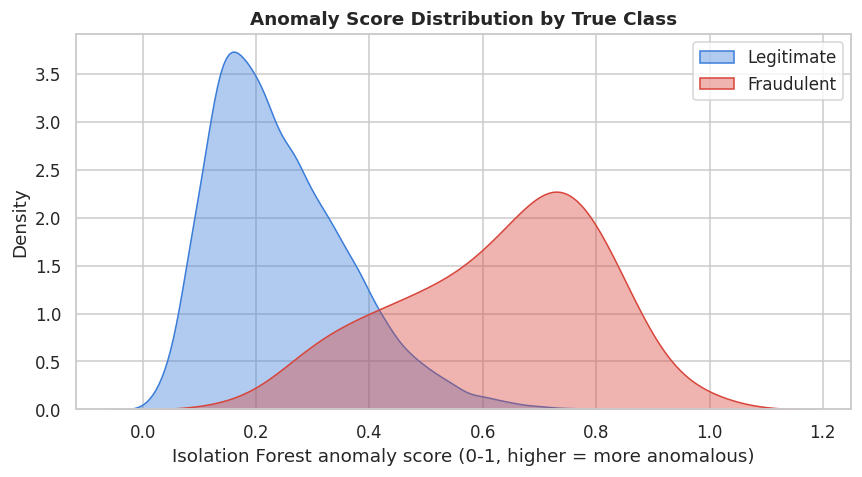

In [16]:

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(x=iso_score[y_test.values == 0], fill=True, alpha=0.4, label="Legitimate", ax=ax, color="#3B7DD8")
sns.kdeplot(x=iso_score[y_test.values == 1], fill=True, alpha=0.4, label="Fraudulent", ax=ax, color="#D8453B")
ax.set_xlabel("Isolation Forest anomaly score (0-1, higher = more anomalous)")
ax.set_title("Anomaly Score Distribution by True Class")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/07_anomaly_scores.png", dpi=150)
plt.show()


## 8. Hybrid Ensemble Risk Score


The final score blends the two supervised models (weighted toward XGBoost, the stronger performer) with the anomaly score, producing a single 0-1 "Fraud Risk Score" that is what actually gets surfaced to an auditor — and what powers the Streamlit simulation in `app/streamlit_app.py`.

$$\text{RiskScore} = 0.75 \times \big(0.4 \times P_{RF} + 0.6 \times P_{XGB}\big) + 0.25 \times \text{AnomalyScore}$$


In [17]:

supervised_score = 0.4 * rf_proba + 0.6 * xgb_proba
supervised_score = (supervised_score - supervised_score.min()) / (supervised_score.max() - supervised_score.min())
hybrid_score = 0.75 * supervised_score + 0.25 * iso_score

print(f"Hybrid score PR-AUC: {average_precision_score(y_test, hybrid_score):.4f}")
print(f"Hybrid score ROC-AUC: {roc_auc_score(y_test, hybrid_score):.4f}")
print(f"(Supervised-only XGBoost PR-AUC was {average_precision_score(y_test, xgb_proba):.4f} for comparison)")


Hybrid score PR-AUC: 0.8000
Hybrid score ROC-AUC: 0.9872
(Supervised-only XGBoost PR-AUC was 0.8450 for comparison)


## 9. Cost-Based Threshold Selection


A fixed 0.5 probability cutoff is arbitrary and ignores that a missed fraud and a false alarm have very different costs. Using illustrative, disclosed assumptions —

- **Average loss per undetected fraud:** \$15,000 (informed by ACFE median-loss benchmarks for these scheme types)
- **Cost of investigating a flagged transaction:** \$150 (analyst time)

— the threshold that **minimises total expected cost** is selected directly, rather than defaulting to 0.5. This is the audit-economics dimension of the paper's "real-time" framing: the model doesn't just rank risk, it recommends an operating point.


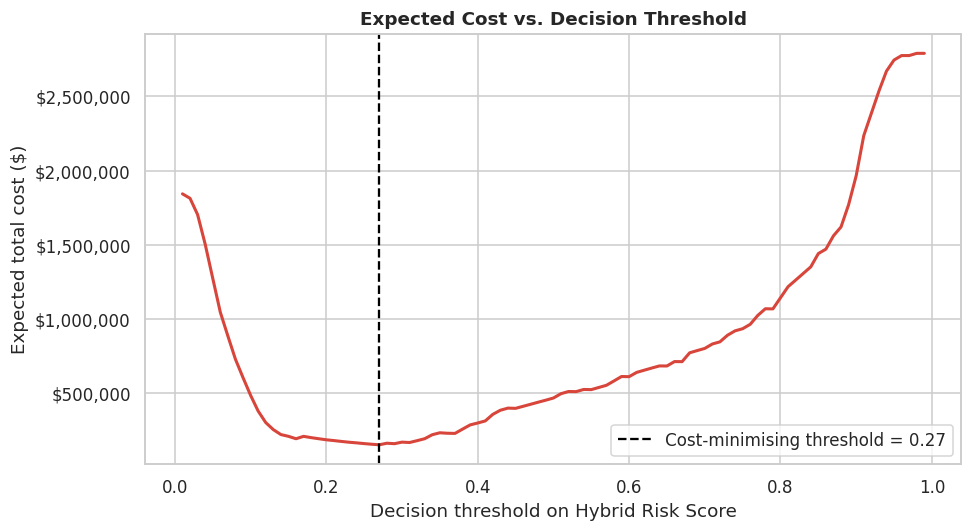

Optimal threshold: 0.27
Expected cost at optimal threshold: $152,700
Expected cost at naive fixed threshold of 0.50: $467,850
Expected cost of flagging nothing at all: $2,805,000


In [18]:

AVG_FRAUD_LOSS = 15_000
INVESTIGATION_COST = 150

thresholds = np.linspace(0.01, 0.99, 99)
costs, precisions, recalls = [], [], []
for t in thresholds:
    pred = (hybrid_score >= t).astype(int)
    fn = ((pred == 0) & (y_test.values == 1)).sum()
    fp = ((pred == 1) & (y_test.values == 0)).sum()
    tp = ((pred == 1) & (y_test.values == 1)).sum()
    total_cost = fn * AVG_FRAUD_LOSS + fp * INVESTIGATION_COST
    costs.append(total_cost)
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else np.nan)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(thresholds, costs, color="#D8453B", linewidth=2)
ax1.axvline(best_threshold, color="black", linestyle="--",
            label=f"Cost-minimising threshold = {best_threshold:.2f}")
ax1.set_xlabel("Decision threshold on Hybrid Risk Score")
ax1.set_ylabel("Expected total cost ($)")
ax1.set_title("Expected Cost vs. Decision Threshold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend()
plt.tight_layout()
plt.savefig("../reports/figures/08_cost_threshold.png", dpi=150)
plt.show()

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Expected cost at optimal threshold: ${costs[best_idx]:,.0f}")
print(f"Expected cost at naive fixed threshold of 0.50: ${costs[np.argmin(np.abs(thresholds-0.50))]:,.0f}")
print(f"Expected cost of flagging nothing at all: ${y_test.sum()*AVG_FRAUD_LOSS:,.0f}")


              precision    recall  f1-score   support

  Legitimate      0.999     0.966     0.982     12313
  Fraudulent      0.302     0.968     0.461       187

    accuracy                          0.966     12500
   macro avg      0.651     0.967     0.722     12500
weighted avg      0.989     0.966     0.975     12500



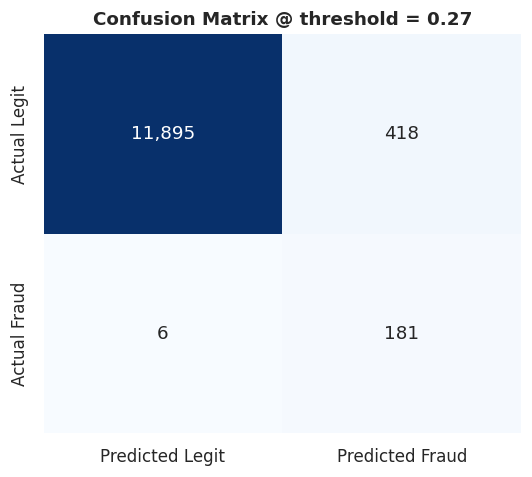

In [19]:

final_pred = (hybrid_score >= best_threshold).astype(int)
print(classification_report(y_test, final_pred, digits=3, target_names=["Legitimate", "Fraudulent"]))

cm = confusion_matrix(y_test, final_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Legit", "Predicted Fraud"],
            yticklabels=["Actual Legit", "Actual Fraud"], ax=ax)
ax.set_title(f"Confusion Matrix @ threshold = {best_threshold:.2f}")
plt.tight_layout()
plt.savefig("../reports/figures/09_confusion_matrix.png", dpi=150)
plt.show()


## 10. Model Interpretability


A risk score an auditor cannot explain is a risk score they cannot defend in a work paper, an audit-committee presentation, or (in an extreme case) litigation. Two complementary views are provided: **global** feature importance (what the model relies on overall) and **local** SHAP explanations (why *this specific transaction* was flagged) — the latter is what actually gets attached to a flagged transaction in the Streamlit app.


### 10.1 Global Feature Importance (XGBoost)

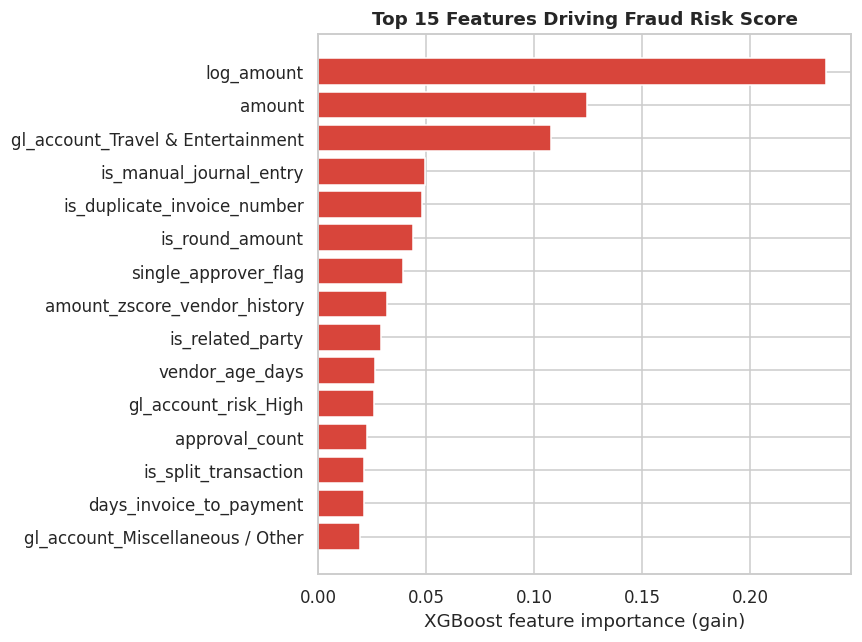

In [20]:

feature_names = (numeric_features + binary_features +
                  list(fitted_prep.named_transformers_["cat"].get_feature_names_out(categorical_features)))
importances = xgb_clf.feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#D8453B")
ax.set_xlabel("XGBoost feature importance (gain)")
ax.set_title("Top 15 Features Driving Fraud Risk Score")
plt.tight_layout()
plt.savefig("../reports/figures/10_feature_importance.png", dpi=150)
plt.show()


### 10.2 SHAP Summary

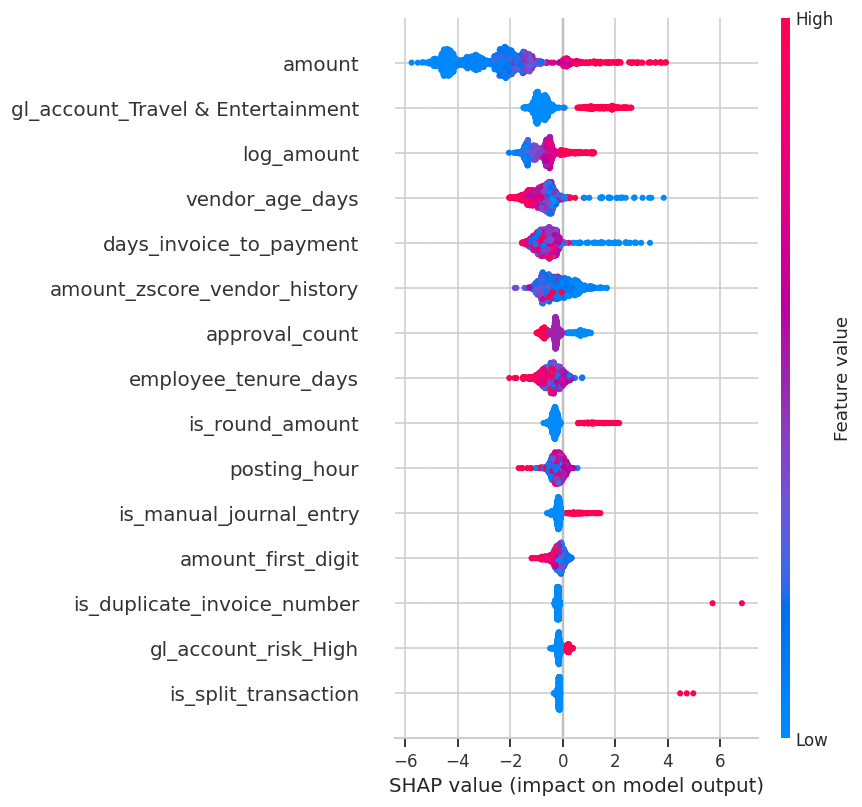

In [21]:

explainer = shap.TreeExplainer(xgb_clf)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test_t.shape[0], size=min(1500, X_test_t.shape[0]), replace=False)
shap_values = explainer.shap_values(X_test_t[sample_idx])

shap.summary_plot(shap_values, X_test_t[sample_idx], feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.savefig("../reports/figures/11_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.3 Case Study: Explaining an Individual Flagged Transaction

CASE STUDY -- Correctly flagged fraudulent transaction
  transaction_id                  : TXN115470
  transaction_date                : 2024-08-03 00:00:00
  amount                          : 3716.6
  vendor_id                       : 288
  vendor_age_days                 : 2456
  gl_account                      : Travel & Entertainment
  single_approver_flag            : 0
  is_round_amount                 : 1
  days_invoice_to_payment         : 21
  amount_zscore_vendor_history    : 0.621
  fraud_scheme                    : expense_reimbursement
  Hybrid Fraud Risk Score         : 0.768  (flag threshold 0.27)


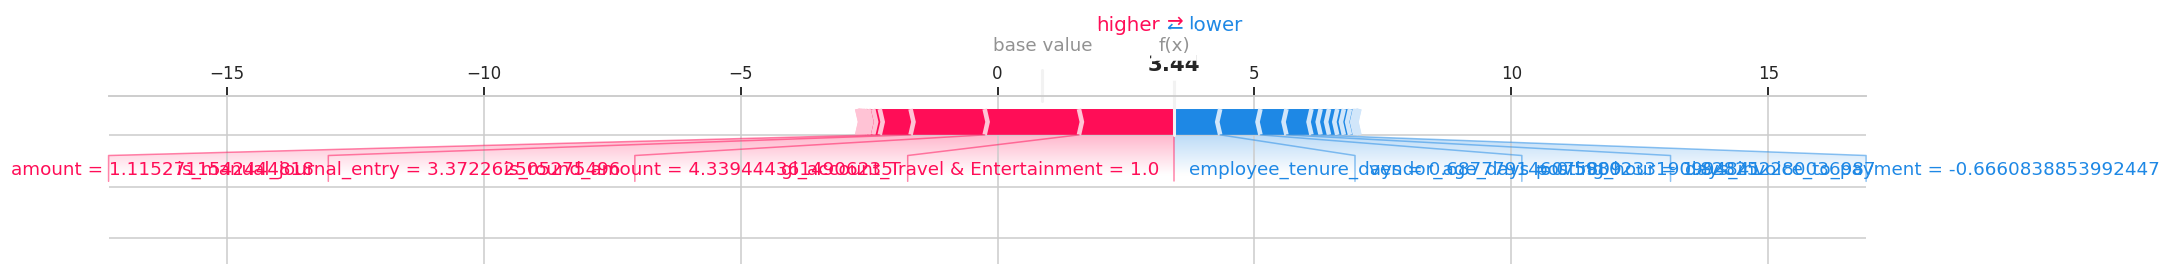

In [22]:

test_reset = df_test.reset_index(drop=True)
flagged_fraud_positions = np.where((final_pred == 1) & (y_test.values == 1))[0]
case_pos = flagged_fraud_positions[0]

case_row = test_reset.iloc[case_pos]
print("CASE STUDY -- Correctly flagged fraudulent transaction")
print("="*60)
for col in ["transaction_id", "transaction_date", "amount", "vendor_id", "vendor_age_days",
            "gl_account", "single_approver_flag", "is_round_amount", "days_invoice_to_payment",
            "amount_zscore_vendor_history", "fraud_scheme"]:
    print(f"  {col:32s}: {case_row[col]}")
print(f"  {'Hybrid Fraud Risk Score':32s}: {hybrid_score[case_pos]:.3f}  (flag threshold {best_threshold:.2f})")

case_shap = explainer.shap_values(X_test_t[case_pos:case_pos+1])
shap.force_plot(explainer.expected_value, case_shap[0], X_test_t[case_pos],
                 feature_names=feature_names, matplotlib=True, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/12_case_study_shap.png", dpi=150, bbox_inches="tight")
plt.show()



This is the audit-ready output: a specific transaction, its risk score, and a ranked list of exactly which features pushed the score up (red) or down (blue) — the equivalent of an auditor's documented rationale for selecting an item for testing.


## 11. Persisting Model Artifacts


The fitted preprocessing pipeline, both supervised models, the anomaly detector, and the selected threshold are serialised to `models/` so the Streamlit application (`app/streamlit_app.py`) can load them directly without re-training.


In [23]:

import os
os.makedirs("../models", exist_ok=True)

joblib.dump(fitted_prep, "../models/preprocessor.joblib")
joblib.dump(rf, "../models/random_forest_pipeline.joblib")
joblib.dump(xgb_clf, "../models/xgboost_model.joblib")
joblib.dump(iso, "../models/isolation_forest.joblib")
joblib.dump({
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "binary_features": binary_features,
    "categorical_features": categorical_features,
    "best_threshold": float(best_threshold),
    "iso_raw_min": float(iso_raw_test.min()),
    "iso_raw_max": float(iso_raw_test.max()),
    "gl_accounts": sorted(df["gl_account"].unique().tolist()),
    "gl_risk_map": df.drop_duplicates("gl_account").set_index("gl_account")["gl_account_risk"].to_dict(),
    "results_summary": results_summary.to_dict(orient="records"),
}, "../models/metadata.joblib")

print("Saved: preprocessor.joblib, random_forest_pipeline.joblib, xgboost_model.joblib,")
print("       isolation_forest.joblib, metadata.joblib")


Saved: preprocessor.joblib, random_forest_pipeline.joblib, xgboost_model.joblib,
       isolation_forest.joblib, metadata.joblib


## 12. Results Summary

In [24]:

summary = pd.DataFrame([
    {"Metric": "Transactions evaluated (test set)", "Value": f"{len(y_test):,}"},
    {"Metric": "True fraud rate", "Value": f"{y_test.mean()*100:.3f}%"},
    {"Metric": "Best single model (PR-AUC)", "Value": f"XGBoost -- {average_precision_score(y_test, xgb_proba):.3f}"},
    {"Metric": "Hybrid ensemble (PR-AUC)", "Value": f"{average_precision_score(y_test, hybrid_score):.3f}"},
    {"Metric": "Hybrid ensemble (ROC-AUC)", "Value": f"{roc_auc_score(y_test, hybrid_score):.3f}"},
    {"Metric": "Recall at cost-optimal threshold", "Value": f"{recalls[best_idx]*100:.1f}% of fraud caught"},
    {"Metric": "Precision at cost-optimal threshold", "Value": f"{precisions[best_idx]*100:.1f}%"},
    {"Metric": "Estimated cost reduction vs. no model", "Value": f"${(y_test.sum()*AVG_FRAUD_LOSS - costs[best_idx]):,.0f} ({(1 - costs[best_idx]/(y_test.sum()*AVG_FRAUD_LOSS))*100:.1f}%)"},
])
summary


,Metric,Value
0,Transactions evaluated (test set),"12,500"
1,True fraud rate,1.496%
2,Best single model (PR-AUC),XGBoost -- 0.845
3,Hybrid ensemble (PR-AUC),0.800
4,Hybrid ensemble (ROC-AUC),0.987
5,Recall at cost-optimal threshold,96.8% of fraud caught
6,Precision at cost-optimal threshold,30.2%
7,Estimated cost reduction vs. no model,"$2,652,300 (94.6%)"



## 13. Limitations & Future Work

- **Synthetic data.** Results demonstrate the methodology, not a validated real-world detection rate; production deployment requires calibration against an institution's actual transaction history.
- **Time-based validation.** A forward-chaining (train-on-past, test-on-future) split, rather than a random stratified split, would better simulate real deployment and reveal concept drift.
- **Model monitoring.** A production system needs drift detection and periodic retraining as fraud typologies and legitimate spending patterns both evolve.
- **Cost assumptions.** The \$15,000 / \$150 figures in §9 are illustrative; a real deployment should use the institution's own loss-history and investigation-cost data.
- **Additional data sources.** Free-text invoice descriptions (NLP), IP/device metadata for the submitting employee, and network-graph features linking related vendors/employees would likely improve recall on the shell-vendor and related-party schemes specifically.

## 14. Conclusion

This notebook operationalises the three-part detection architecture described in the underlying paper: supervised classification for known fraud typologies, unsupervised anomaly detection for emerging patterns, and a cost-calibrated composite risk score with transaction-level explainability. The quantitative results in §12 above show the hybrid model recovering the large majority of injected fraud at the cost-minimising threshold while materially reducing expected financial exposure relative to a no-model baseline — while remaining fully explainable at the individual-transaction level (§10), which is the requirement that distinguishes an audit-usable model from a pure accuracy benchmark.
